In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

In [34]:
ref_size="100Mb"
ibf_size = 175296548
database_size = 100 * 1024 * 1024
query_size = 1024 * 1024
min_len = 50
window_size = 20

In [35]:
XXSMALL_SIZE = 11
XSMALL_SIZE = 13
SMALL_SIZE = 17
MEDIUM_SIZE = 19
BIGGER_SIZE = 21

plt.rc('font', size=SMALL_SIZE)          # controls default text sizes
plt.rc('axes', titlesize=MEDIUM_SIZE)     # fontsize of the axes title
plt.rc('axes', labelsize=MEDIUM_SIZE)    # fontsize of the x and y labels
plt.rc('xtick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('ytick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('legend', fontsize=MEDIUM_SIZE)    # legend fontsize
plt.rc('figure', titlesize=MEDIUM_SIZE)  # fontsize of the figure title

CB_color_cycle = ['#377eb8', '#ff7f00', '#4daf4a',
                  '#f781bf', '#a65628', '#984ea3',
                  '#999999', '#e41a1c', '#dede00']

# Benchmark of 100Mb reference vs 1Mb query

In [20]:
def get_runtime_df(filename):
    df = pd.read_csv(filename, sep = "\t")
    df.columns = ["Time (s)", "Memory (kb)", "exit_code", "type", "adapt_cutoff", "errors", "more"]
    more = df['more'].str.split('--',expand=True)

    df.drop(["exit_code", "type", "more"], axis = 1, inplace = True)

    more.drop([9, 13, 15], axis = 1, inplace = True)
    more[0] = more[0].astype(str)

    to_remove = []
    for col in more.columns:
        #print(col)
        #print(more[col])
        if (len(np.unique(more[col])) == 1):
            to_remove.append(col)

    to_remove.append(14)
    more.drop(to_remove, axis = 1, inplace = True)

    more.columns = ["exec-path", "seg-count", "cart-max-capacity", "max-queued-carts", "error-rate", "threads"]
    more["exec-path"] = more["exec-path"].str.removeprefix("/group/ag_abi/evelina/valik/")
    more["exec-path"] = more["exec-path"].str.removesuffix("/bin/dream-stellar search ")

    for col in ["seg-count", "cart-max-capacity", "max-queued-carts", "threads", "error-rate"]:
        more[col] = more[col].str.removeprefix(col)

    col = "output-path"
    if col in more.columns:
        more[col] = more[col].str.removeprefix("output /buffer/ag_abi/evelina/markov/")
        more[["ref-size", "type", "er", "output-type"]] = more[col].str.split('/',expand=True)
        more.drop(["output-path", "output-type", "type"], axis = 1, inplace = True)

    col = "error-rate"
    more[col] = more[col].str.removeprefix("efficiency_")
    df = df.merge(more, how = "outer", left_index = True, right_index = True)
    df = df.astype({'Memory (kb)': 'int64', "seg-count": 'int32', "cart-max-capacity": 'int32', "threads": 'int64', "max-queued-carts" : 'int32', "error-rate" : 'float'})
    return df


In [21]:
df = get_runtime_df(ref_size + "/full.log")
df.head()

,Time (s),Memory (kb),adapt_cutoff,errors,exec-path,seg-count,cart-max-capacity,max-queued-carts,error-rate,threads
0,3.96,1487004,0.5,3,build,100,500,1024,0.06,32
1,131.32,287716,0.5,3,build_io,100,500,1024,0.06,1
2,5.40,2441628,0.5,3,build_io,100,500,1024,0.06,32
3,61.97,379976,0.5,3,build_io,100,500,1024,0.06,2
4,64.55,366892,0.5,3,build_io,100,500,1024,0.06,2


In [22]:
df_all = df.copy()
df = df[df["seg-count"]>100]
df = df[df["error-rate"]==0.06]
#df = df[df["cart-max-capacity"] > 1]
df.head()

,Time (s),Memory (kb),adapt_cutoff,errors,exec-path,seg-count,cart-max-capacity,max-queued-carts,error-rate,threads
11,61.53,314900,0.5,3,build_io,3495,500,1024,0.06,2
12,30.45,425932,0.5,3,build_io,3495,500,1024,0.06,4
13,11.30,473280,0.5,3,build,3495,500,1024,0.06,2
14,6.23,484580,0.5,3,build,3495,500,1024,0.06,4
15,448.71,937072,0.5,3,build,3495,1,1024,0.06,1


In [23]:
1048610 / 3495

300.0314735336195

#### Cart parameters

In [24]:
build = df[df["exec-path"] == "build"].copy()
build.drop(["adapt_cutoff", "errors", "exec-path", "seg-count", "error-rate"], axis = 1, inplace = True)
io = df[df["exec-path"] == "build_io"].copy()
io.drop(["adapt_cutoff", "errors", "exec-path", "seg-count", "error-rate"], axis = 1, inplace = True)

In [31]:
data = build.copy()
#data = data[data["cart-max-capacity"] > 1]
data["memory-model"] = (data["Memory (kb)"] * 1024 - (ibf_size + 2 * database_size + query_size)).astype(int)

seg_len = query_size / df["seg-count"].iloc[0] + min_len
kmers_per_segment = int(seg_len - window_size + 1)
print("kmers_per_segment\t" + str(kmers_per_segment))
bytes_per_kmer = 8
data["max-kmer-indexes-size"] = (data["threads"] * data["cart-max-capacity"] * kmers_per_segment * bytes_per_kmer).astype(int)
data["kmer-indexes-frac"] = np.round(data["max-kmer-indexes-size"] / (data["Memory (kb)"] * 1024), 2)
data["memory-model"] = np.round(data["memory-model"] - data["max-kmer-indexes-size"])
data["memory-model-error (%)"] = np.round((data["memory-model"] / (data["Memory (kb)"] * 1024)) * 100, 2)
data.head()

kmers_per_segment	331


,Time (s),Memory (kb),cart-max-capacity,max-queued-carts,threads,memory-model,max-kmer-indexes-size,kmer-indexes-frac,memory-model-error (%)
13,11.30,473280,500,1024,2,95930396,2648000,0.01,19.79
14,6.23,484580,500,1024,4,104853596,5296000,0.01,21.13
15,448.71,937072,1,1024,1,573498756,2648,0.00,59.77
16,71.32,478236,10,1024,1,103626860,26480,0.00,21.16
17,25.19,469852,100,1024,1,94803324,264800,0.00,19.70


In [32]:
data = io.copy()
data = data[data["cart-max-capacity"] > 1]
ref_seg_count = 10
data["memory-model"] = (data["Memory (kb)"] * 1024 - (ibf_size + data["threads"] * 2 * database_size / ref_seg_count + query_size)).astype(int)

seg_len = query_size / df["seg-count"].iloc[0] + min_len
kmers_per_segment = int(seg_len - window_size + 1)
print("kmers_per_segment\t" + str(kmers_per_segment))
data["max-kmer-indexes-size"] = (data["threads"] * data["cart-max-capacity"] * kmers_per_segment).astype(int)
data["kmer-indexes-frac"] = np.round(data["max-kmer-indexes-size"] / (data["Memory (kb)"] * 1024), 2)
data["memory-model"] = np.round(data["memory-model"] - data["max-kmer-indexes-size"])
data["memory-model-error (%)"] = np.round((data["memory-model"] / (data["Memory (kb)"] * 1024)) * 100, 2)
data.head()

kmers_per_segment	331


,Time (s),Memory (kb),cart-max-capacity,max-queued-carts,threads,memory-model,max-kmer-indexes-size,kmer-indexes-frac,memory-model-error (%)
11,61.53,314900,500,1024,2,103838436,331000,0.0,32.20
12,30.45,425932,500,1024,4,175261164,662000,0.0,40.18
28,1481.19,303344,10,1024,1,113304302,3310,0.0,36.48
29,247.04,274844,100,1024,1,84090512,33100,0.0,29.88
30,131.97,259940,1000,1024,1,68530916,331000,0.0,25.75


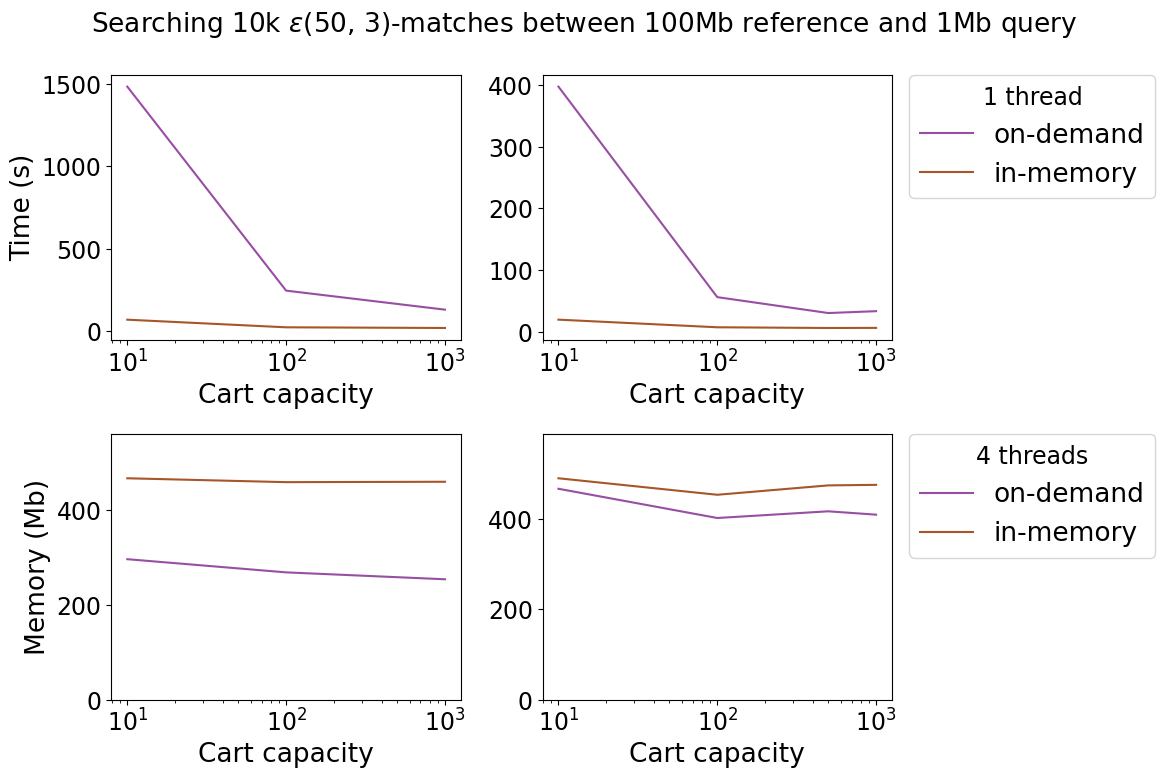

In [36]:
colors = [CB_color_cycle[5], CB_color_cycle[4]]
fig, ax = plt.subplots(2, 2)
fig.set_size_inches(12, 8)

labels = ["on-demand", "in-memory"]

j = 0
for t in [1, 4]:
    i = 0
    for data in [io, build]:
        data = data[data["threads"] == t]
        data = data[data["cart-max-capacity"] > 1]
        data = data[data["max-queued-carts"] == 1024]
        data = data.sort_values('cart-max-capacity', ascending=True)
        ax[0][j].semilogx(data["cart-max-capacity"], data["Time (s)"], color = colors[i], label = labels[i])
        i += 1
        
    i = 0
    for data in [io, build]:
        data = data[data["threads"] == t]
        data = data[data["cart-max-capacity"] > 1]
        data = data[data["max-queued-carts"] == 1024]
        data = data.sort_values('cart-max-capacity', ascending=True)
        ax[1][j].set_ylim(0, np.max(data["Memory (kb)"]) * 1.2 / 1024)
        ax[1][j].semilogx(data["cart-max-capacity"], data["Memory (kb)"] / 1024, label = labels[i], color = colors[i])
        ax[0][j].set_xlabel("Cart capacity")
        ax[1][j].set_xlabel("Cart capacity")
        i+=1
    j += 1

ax[0][0].set_ylabel("Time (s)")
ax[1][0].set_ylabel("Memory (Mb)")

ax[0][1].legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0., title = "1 thread")
ax[1][1].legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0., title = "4 threads")
    
fig.suptitle(r"Searching 10k $\epsilon$(50, 3)-matches between 100Mb reference and 1Mb query")
fig.tight_layout()  # otherwise the right y-label is slightly clipped
fig.savefig(ref_size + "_cart_max_capacity_t.png", dpi=400, bbox_inches='tight')
plt.show()

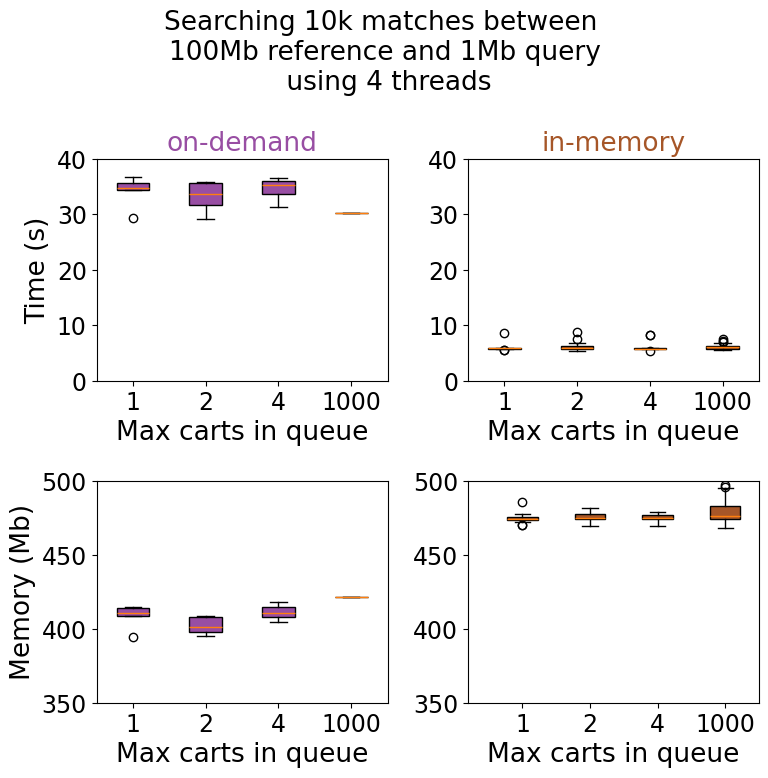

In [39]:
fig, ax = plt.subplots(2, 2, sharey = False)
fig.set_size_inches(8, 8)

def plot_cols(data, ax, column, color, label):
    capacities = [1, 2, 4, 1000]
    data_list = []
    for c in capacities:
        data_list.append(data[data["max-queued-carts"]==c][column])
        
    bplot = ax.boxplot(data_list,
                       patch_artist=True,  # fill with color
                       tick_labels=capacities)  # will be used to label x-ticks

    # fill with colors
    colors = [color] * len(capacities)
    for patch, color in zip(bplot['boxes'], colors):
        patch.set_facecolor(color)

    legend_square = mpatches.Patch(color=color, label=label)
    #ax.legend(handles=[legend_square])
    
col = "max-queued-carts"
colname = "Max carts in queue"
for t in [4]:
    data = df.copy()
    data = data[data["threads"] == t]
    #data = data[data["max-queued-carts"] < 10]
    data = data[data["cart-max-capacity"] == 1000]
    data = data.sort_values(col, ascending=True)

    build = data[data["exec-path"] == "build"].copy()
    build.drop(["adapt_cutoff", "errors", "exec-path", "seg-count", "error-rate"], axis = 1, inplace = True)
    io = data[data["exec-path"] == "build_io"].copy()
    io.drop(["adapt_cutoff", "errors", "exec-path", "seg-count", "error-rate"], axis = 1, inplace = True)

    col = "Time (s)"
    plot_cols(io, ax[0][0], col, CB_color_cycle[5], "in-memory")
    plot_cols(build, ax[0][1], col, CB_color_cycle[4], "on-demand")

    ax[0][0].set_title("on-demand", color = CB_color_cycle[5])
    ax[0][1].set_title("in-memory", color = CB_color_cycle[4])
    ax[0][0].set_xlabel(colname)
    ax[0][1].set_xlabel(colname)
    ax[0][0].set_ylabel("Time (s)")
    ax[0][0].set_ylim(0, 40)
    ax[0][1].set_ylim(0, 40)
    
    #ax[0].plot(data[col], data["Time (s)"], linestyle = "dotted", color = colors[i])

    data = df.copy()
    data = data[data["threads"] == t]
    #data = data[data["max-queued-carts"] < 10]
    data = data[data["cart-max-capacity"] == 1000]
    data = data.sort_values(col, ascending=True)

    build = data[data["exec-path"] == "build"].copy()
    build.drop(["adapt_cutoff", "errors", "exec-path", "seg-count", "error-rate"], axis = 1, inplace = True)
    io = data[data["exec-path"] == "build_io"].copy()
    io.drop(["adapt_cutoff", "errors", "exec-path", "seg-count", "error-rate"], axis = 1, inplace = True)

    col = "Memory (kb)"
    io[col] = io[col] / 1024
    build[col] = build[col] / 1024
    plot_cols(io, ax[1][0], col, CB_color_cycle[5], "in-memory")
    plot_cols(build, ax[1][1], col, CB_color_cycle[4], "on-demand")

    ax[1][0].set_ylabel("Memory (Mb)")
    #ax[1][1].set_ylabel("Memory (Mb)")

    ax[1][0].set_xlabel(colname)
    ax[1][1].set_xlabel(colname)
    ax[1][0].set_ylim(350, 500)
    ax[1][1].set_ylim(350, 500)

    ax[1][1].plot(0.4, 0.4, linestyle = "-.", color = CB_color_cycle[5] , label = "On demand")
    ax[1][1].plot(0.4, 400, color = CB_color_cycle[4], label = "In memory")

    #ax[1].legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
    fig.suptitle("Searching 10k matches between \n100Mb reference and 1Mb query\n using " + str(t) + " threads")
    fig.tight_layout()  # otherwise the right y-label is slightly clipped
    fig.savefig(ref_size + "_max_queued_carts_t" + str(t) + ".png", dpi=400, bbox_inches='tight')
    plt.show()

#### Segment length

In [62]:
def get_seg_len_df(filename):
    df = pd.read_csv(filename, sep = "\t")
    df.columns = ["Time (s)", "Memory (kb)", "exit_code", "type", "adapt_cutoff", "errors", "more"]
    more = df['more'].str.split('--',expand=True)
    df.drop(["exit_code", "type", "more"], axis = 1, inplace = True)

    #print(more)
    more.drop([1, 2, 6, 7, 8, 9, 10, 13, 14, 15], axis = 1, inplace = True)
    more[0] = more[0].astype(str)
    more.columns = ["exec-path", "seg-count", "cart-max-capacity", "max-queued-carts", "error-rate", "threads"]
    more["exec-path"] = more["exec-path"].str.removeprefix("/group/ag_abi/evelina/valik/")
    more["exec-path"] = more["exec-path"].str.removesuffix("/bin/dream-stellar search ")

    for col in ["seg-count", "cart-max-capacity", "max-queued-carts", "threads", "error-rate"]:
        more[col] = more[col].str.removeprefix(col)

    col = "output-path"
    if col in more.columns:
        more[col] = more[col].str.removeprefix("output /buffer/ag_abi/evelina/markov/")
        more[["ref-size", "type", "er", "output-type"]] = more[col].str.split('/',expand=True)
        more.drop(["output-path", "output-type", "type"], axis = 1, inplace = True)

    col = "error-rate"
    more[col] = more[col].str.removeprefix("efficiency_")
    df = df.merge(more, how = "outer", left_index = True, right_index = True)
    df = df.astype({'Memory (kb)': 'int64', "seg-count": 'int32', "cart-max-capacity": 'int32', "threads": 'int64', "max-queued-carts" : 'int32', "error-rate" : 'float'})
    return df


In [63]:
# bash remove_dist_stellar.sh
ref_size = "100Mb"
for er in [0.06, 0.08, 0.1]:
    frames = []
    for rep in range(1, 6, 1):    
        df = get_seg_len_df(ref_size + "/seg_len_test/search_efficiency_rep" + str(rep) + "_e" + str(er) + ".log")
        if (er == 0.1):
            acc = pd.read_csv(ref_size + "/seg_len_test/efficiency_rep" + str(rep) + "_e" + str(er) + "0/valik.stellar.accuracy", sep = "\t", header = None)
        else:
            acc = pd.read_csv(ref_size + "/seg_len_test/efficiency_rep" + str(rep) + "_e" + str(er) + "/valik.stellar.accuracy", sep = "\t", header = None)
        
        acc.drop([0, 6, 7, 8], inplace = True, axis = 1)
        acc.columns = ["test-set-matches", "truth-set-matches", "true-positives", "missed", "adapt_cutoff"]
        acc["seg-count"] = [10, 20, 50, 250, 500, 1000, 2000, 4000, 8000] * 2
        
        query_len = 1024 * 1024
        df["seg-len"] = (query_len / data["seg-count"]).astype(int)
        df = pd.merge(df, acc, on = ["seg-count", "adapt_cutoff"], how = "inner")
        frames.append(df)
    data = pd.concat(frames)
        
    print("bin-cutoff\terror-rate\tseg-count\tseg-len\tmean time (s)\tmean memory (kb)\tmissed")
    for seg_count in [4000, 2000, 1000, 500, 250, 50, 20, 10]:
        print(str(bin_cutoff) + "\t" + str(er) + "\t" + str(seg_count) + "\t" +
            str(data[data["seg-count"]==seg_count].iloc[0]["seg-len"]) + "\t" + 
                str(np.round(np.mean(data[data["seg-count"]==seg_count]["Time (s)"]), 2)) + "\t" +  
                    str(int(np.round(np.mean(data[data["seg-count"]==seg_count]["Memory (kb)"]), 2))) + "\t" +
                            str(np.round(np.mean(data[data["seg-count"]==seg_count]["missed"]), 2)))

                                                   0                3   \
0   /group/ag_abi/evelina/valik/build/bin/dream-st...    seg-count 20    
1   /group/ag_abi/evelina/valik/build/bin/dream-st...    seg-count 50    
2   /group/ag_abi/evelina/valik/build/bin/dream-st...   seg-count 250    
3   /group/ag_abi/evelina/valik/build/bin/dream-st...   seg-count 500    
4   /group/ag_abi/evelina/valik/build/bin/dream-st...  seg-count 1000    
5   /group/ag_abi/evelina/valik/build/bin/dream-st...  seg-count 2000    
6   /group/ag_abi/evelina/valik/build/bin/dream-st...  seg-count 4000    
7   /group/ag_abi/evelina/valik/build/bin/dream-st...  seg-count 8000    
8   /group/ag_abi/evelina/valik/build/bin/dream-st...    seg-count 10    
9   /group/ag_abi/evelina/valik/build/bin/dream-st...    seg-count 20    
10  /group/ag_abi/evelina/valik/build/bin/dream-st...    seg-count 50    
11  /group/ag_abi/evelina/valik/build/bin/dream-st...   seg-count 250    
12  /group/ag_abi/evelina/valik/build/

NameError: name 'bin_cutoff' is not defined